# Accessible PlantUML Activity Diagrams

This notebook demonstrates how to create an accessibility-aware activity diagram in PlantUML from Python.

## What this diagram is used for

Activity diagrams represent workflows, algorithms, and procedural logic.

## How to make it more accessible

Use clearly labeled actions, minimize unnecessary branching, describe decisions explicitly, and keep the workflow simple enough to narrate step by step. A textual explanation should make the purpose and branch logic clear without depending on spatial layout.

## Setup

These notebooks use **Python to write PlantUML source code and call PlantUML locally** to render the diagram.

PlantUML must therefore be available on your system. A local PlantUML installation requires Java, and some diagram types may also require Graphviz.

You can use PlantUML in either of these ways:

1. **Install the PlantUML command-line tool** using the package manager available on your operating system.
2. **Download `plantuml.jar`** from the PlantUML website and run it with Java.

After installation, verify that PlantUML is available by running:

```bash
plantuml -version
```

If you use a downloaded `plantuml.jar` instead of a `plantuml` command, set the `PLANTUML_JAR` environment variable to the path of the JAR file before running the notebook.

The Python helper below supports both approaches.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess

from IPython.display import Image, display


def render_plantuml(source, filename):
    """Save PlantUML source, render it as PNG, and display it."""
    source_path = Path(f"{filename}.puml")
    source_path.write_text(source, encoding="utf-8")

    plantuml_executable = shutil.which("plantuml")
    plantuml_jar = os.environ.get("PLANTUML_JAR")

    if plantuml_executable:
        command = [
            plantuml_executable,
            "-charset", "UTF-8",
            "-tpng",
            str(source_path),
        ]
    elif plantuml_jar:
        command = [
            "java",
            "-jar",
            plantuml_jar,
            "-charset", "UTF-8",
            "-tpng",
            str(source_path),
        ]
    else:
        raise RuntimeError(
            "PlantUML was not found. Install the 'plantuml' command "
            "or set PLANTUML_JAR to the path of plantuml.jar."
        )

    result = subprocess.run(command, capture_output=True, text=True)

    if result.returncode != 0:
        raise RuntimeError("PlantUML rendering failed:\n" + result.stderr)

    image_path = source_path.with_suffix(".png")
    if not image_path.exists():
        raise FileNotFoundError(f"Rendered image was not created: {image_path}")

    display(Image(filename=str(image_path)))
    return image_path


## Accessible example

The example below creates an accessibility-aware activity diagram also presented in the Guidelines document.

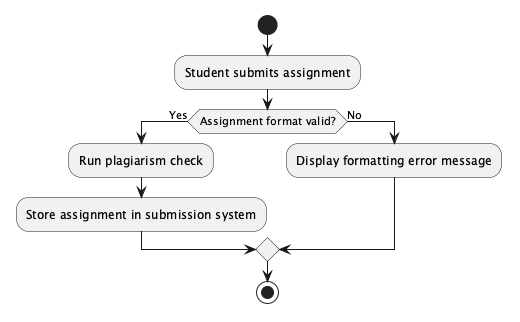

PosixPath('accessible_activity_diagram.png')

In [ ]:
activity_source = """@startuml
skinparam dpi 300
start
:Student submits assignment;

if (Assignment format valid?) then (Yes)
  :Run plagiarism check;
  :Store assignment in submission system;
else (No)
  :Display formatting error message;
endif

stop
@enduml
"""

render_plantuml(activity_source, "accessible_activity_diagram")

## Accessible description

Activity diagram for student assignment submission. The process starts when the student submits an assignment. The system checks whether the assignment format is valid. If it is valid, the system runs a plagiarism check and stores the assignment. If it is not valid, the system displays a formatting error message. Both branches then terminate.

## Reusable accessible template

Replace the placeholder actions and decision with meaningful steps and explicit branch labels from your own workflow.

In [ ]:
activity_template = """@startuml
start
:Describe the initial action;

if (State the decision clearly?) then (Yes)
  :Describe the action on the Yes branch;
  :Describe the next action;
else (No)
  :Describe the action on the No branch;
endif

stop
@enduml
"""

render_plantuml(activity_template, "activity_diagram_template")

## Accessible description template

After replacing the placeholder source with your own activity diagram, add a concise textual description that:

- identifies the diagram type and purpose,
- names the important entities, classes, actions, states, or nodes,
- explains the relationships or interaction order,
- describes decision or transition logic where relevant,
- and states the key structural takeaway.

Do not rely on spatial wording alone. The description should communicate the important relationships encoded by the diagram.
